## Caricamento dei dati TH, visualizzazione predizioni MPC
Carichiamo il file JSON contenente le soluzioni dell'MPC.

In [1]:
# 1. Import delle librerie
import json
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

# 2. Definisco il percorso alla cartella e al file
base_dir_th = Path(r"C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/"
                "ControlloDistribuito_DERTF/DatiDERTF_Rapporto/"
                "Centralizzato_mqtt_TH_EL/TH/SolutionData")
file_name_th = "Solution_t0_tHl0_17_41.json"         # Modificare orario in base al primo file json  ##########################
file_path_th = base_dir_th / file_name_th

# 3. Controllo che il file esista
assert file_path_th.exists(), f"File non trovato: {file_path_th}"

# 4. Carico il JSON in un dict Python
with file_path_th.open("r", encoding="utf-8") as f:
    data_th = json.load(f)


## Esplorazione delle variabili
Generatori

In [ ]:
import pandas as pd
# 2. Costruzione records “wide”
records = []
for gen_name, gen in data_th["Generators"].items():
    # assumiamo che tutte le metriche abbiano la stessa lunghezza
    n_steps = len(next(iter(gen.values())))
    for step in range(n_steps):
        rec = {"generator": gen_name, "step": step}
        # ciclo su ciascuna metrica del generatore
        for metric, values in gen.items():
            rec[metric] = values[step]
        records.append(rec)

# 3. DataFrame “wide”
df_wide = pd.DataFrame(records)
df_wide.head()

## Visualizzazione delle soluzioni MPC
Creiamo grafici per visualizzare l'andamento delle variabili nel tempo.

In [ ]:
import matplotlib.pyplot as plt
metrics = ["GenIn", "m", "T_in", "T_out", "Out1", "Out2"]  # lista delle metriche da plottare

for metric in metrics:
    fig, ax = plt.subplots(figsize=(8, 4))
    for gen in df_wide["generator"].unique():
        dfg = df_wide[df_wide["generator"] == gen]
        ax.plot(dfg["step"], dfg[metric], marker="o", label=gen)
    ax.set_title(f"{metric} vs Step")
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True)
    plt.show()


# SETPOINT INVIATI DAL MPC TH
In questa sezione vengono salvati e concatenati i primi valori delle soluzione dell'MPC che corrispondono ai setpoint inviati all'impianto

In [69]:
# 1. Import delle librerie
import os
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import re
from datetime import datetime


# === Configura il percorso della cartella con i file JSON ===
folder_path_TH = 'C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/TH/SolutionData/'  # Cambia questo percorso se i file sono in una cartella diversa
json_files_TH = [f for f in os.listdir(folder_path_TH) if f.startswith("Solution") and f.endswith(".json")]

# === Contenitore dei setpoint iniziali ===
setpoints = []

def get_numeric_sort_key(filename):
    """
    Extracts the numeric part from filenames like 'Solution_tX_tHl0_12_43 1.json'
    for numerical sorting.
    """
    match = re.search(r'_t(\d+)_', filename)
    if match:
        return int(match.group(1))
    return float('inf') # Put files without a number at the end


# Sort the files numerically
sorted_json_files_TH = sorted(json_files_TH, key=get_numeric_sort_key)

# display last elements of the list (list has no .tail())
display(pd.Series(sorted_json_files_TH).tail())

19    Solution_t19_tHl3_22_47.json
20    Solution_t20_tHl3_23_01.json
21    Solution_t21_tHl3_23_15.json
22    Solution_t22_tHl3_23_30.json
23    Solution_t23_tHl3_23_45.json
dtype: object

Salvataggio dei valori iniziali di ogni sequenza (sono i setpoint inviati)

In [ ]:
from datetime import datetime, timedelta

def extract_first_values(d):
    result = {}
    for key, value in d.items():
        if isinstance(value, dict):
            nested = extract_first_values(value)
            if nested:
                result[key] = nested
        elif isinstance(value, list) and value:
            result[key] = value[0]
    return result

# Lista per raccogliere tutti i setpoints
all_setpoints_TH = []

# Itera sui file ordinati
for filename in sorted_json_files_TH:
    file_path = os.path.join(folder_path_TH, filename)
    with open(file_path, 'r') as f:
        data = json.load(f)

    setpoints = {
        key: extract_first_values(data[key])
        for key in ['Generators', 'HeatingLoads', 'Storages']
        if key in data
    }

    # Aggiungi il nome del file per riferimento
    setpoints["File"] = filename
    
    # Imposta la data di inizio (esempio: 2025-10-07)
    start_date = datetime(2025, 8, 5)                               ########################################################
    
    # Estrai orario: ultime due coppie numeriche da nome file json
    # Esempio: 'Solution_t0_tHl0_12_43.json' diventa '12_43'
    parts = filename.replace('.json', '').split('_')
    if len(parts) >= 3:
        hour = int(parts[-2])
        minute = int(parts[-1])
        # Crea solo l'orario
        time_only = datetime.strptime(f"{hour}_{minute}", "%H_%M").time()
        # Se l'orario è >= 00:00 e < 12:00, considera giorno successivo
        if hour < 12:
            day = start_date + timedelta(days=1)
        else:
            day = start_date
        # Combina giorno e orario
        time_obj = datetime.combine(day.date(), time_only)
    else:
        raise ValueError(f"Formato nome file non valido: {filename}")

    # Aggiungi il timestamp e il nome del file
    setpoints["Time"] = time_obj
    all_setpoints_TH.append(setpoints)


df_th = pd.DataFrame(all_setpoints_TH)
print(len(df_th))


# Imposta la colonna Time come indice
df_th.set_index("Time", inplace=True)

display(df_th.head())
display(df_th.tail())

## Plot setpoint generatori

In [ ]:
# Estrai tutti i sistemi 
sistemi_TH_Gen = df_th['Generators'].iloc[0].keys()

for sistema in sistemi_TH_Gen:
    # Estrai i valori 'm' per ciascun sistema
    m_values = df_th['Generators'].apply(lambda x: x[sistema]['m'])

    plt.figure(figsize=(8, 3))
    plt.step(m_values.index, m_values, where='post', label=f'{sistema} - m')
    plt.xlabel("Indice scenario/file")
    plt.ylabel("Portata (m)")
    plt.title(f"Portata per {sistema} da file JSON")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for sistema in sistemi_TH_Gen:
    # Estrai i valori 'T_out' per ciascun sistema
    T_out_values = df_th['Generators'].apply(lambda x: x[sistema]['T_out'])

    plt.figure(figsize=(8, 3))
    plt.step(T_out_values.index, T_out_values, where='post', label=f'{sistema} - T_out')
    plt.xlabel("Indice scenario/file")
    plt.ylabel("Temperatura (T_out)")
    plt.title(f"T_out per {sistema} da file JSON")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Plot Setpoint carichi

In [ ]:
# Estrai tutti i sistemi 
sistemi_TH_Load = df_th['HeatingLoads'].iloc[0].keys()


for sistema in sistemi_TH_Load:
    # Estrai i valori 'm' per ciascun sistema
    T_out_values = df_th['HeatingLoads'].apply(lambda x: x[sistema]['T_out'])
    
    plt.figure(figsize=(8, 3))
    plt.step(T_out_values.index, T_out_values, where='post', label=f'{sistema} - Tout')
    plt.xlabel("Indice scenario/file")
    plt.ylabel("Temperatura (T_out)")
    plt.title(f"T_out per {sistema} da file JSON")
    plt.legend()
    plt.grid(True)
     # 👉 Mostra solo l'orario sull'asse X
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    
    plt.show()

for sistema in sistemi_TH_Load:
    # Estrai i valori 'ThermalPower' per ciascun sistema
    P_values = df_th['HeatingLoads'].apply(lambda x: x[sistema]['ThermalPower'])

    plt.figure(figsize=(8, 3))
    plt.step(P_values.index, P_values, where='post', label=f'{sistema} - P')
    plt.xlabel("Indice scenario/file")
    plt.ylabel("Potenza (kW)")
    plt.title(f"Potenza per {sistema} da file JSON")
    plt.legend()
    plt.grid(True)
     # 👉 Mostra solo l'orario sull'asse X
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    
    plt.show()


Salvataggio misure reali da file .csv

In [ ]:
import pandas as pd

# Carica il file CSV e interpreta la colonna 'Time' come datetime
df_meas_TH_HeatingLoads = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/TH-MPC set points and measurements _ heating loads-data-as-joinbyfield-2025-08-06 08_43_23.csv", parse_dates=['Time'])

# Carica il file CSV e interpreta la colonna 'Time' come datetime
df_meas_TH_Generators = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/TH-MPC set points and measurements _ generation-data-as-joinbyfield-2025-08-06 08_43_14.csv", parse_dates=['Time'])


def filter_df_by_file_times(df, sorted_json_files):
    """
    Filtra il DataFrame `df` per includere solo le righe con orari compresi
    tra quelli indicati nei nomi del primo e dell'ultimo file in `sorted_json_files_TH`.
    
    I nomi dei file devono contenere l'orario nel formato '_HH_MM' prima dell'estensione '.json'.
    La colonna 'Time' del DataFrame deve essere in formato datetime.
    """
    
    def extract_time_from_filename(filename):
        match = re.search(r'_(\d{2})_(\d{2})', filename)
        if match:
            hour, minute = match.groups()
            return datetime.strptime(f"{hour}:{minute}", "%H:%M").time()
        return None

    # Estrai orari dai file
    start_time = extract_time_from_filename(sorted_json_files[0])
    end_time = extract_time_from_filename(sorted_json_files[-1])

    if start_time is None or end_time is None:
        raise ValueError("Impossibile estrarre orari validi dai nomi dei file.")

    # Assicurati che la colonna 'Time' sia in formato datetime
    df['Time'] = pd.to_datetime(df['Time'])

    # Filtra il DataFrame per orario
    df_filtered = df[df['Time'].dt.time.between(start_time, end_time)]

    return df_filtered


df_meas_TH_HeatingLoads = filter_df_by_file_times(df_meas_TH_HeatingLoads, sorted_json_files_TH)
df_meas_TH_Generators = filter_df_by_file_times(df_meas_TH_Generators, sorted_json_files_TH)



## Plot Setpoint e misure carichi

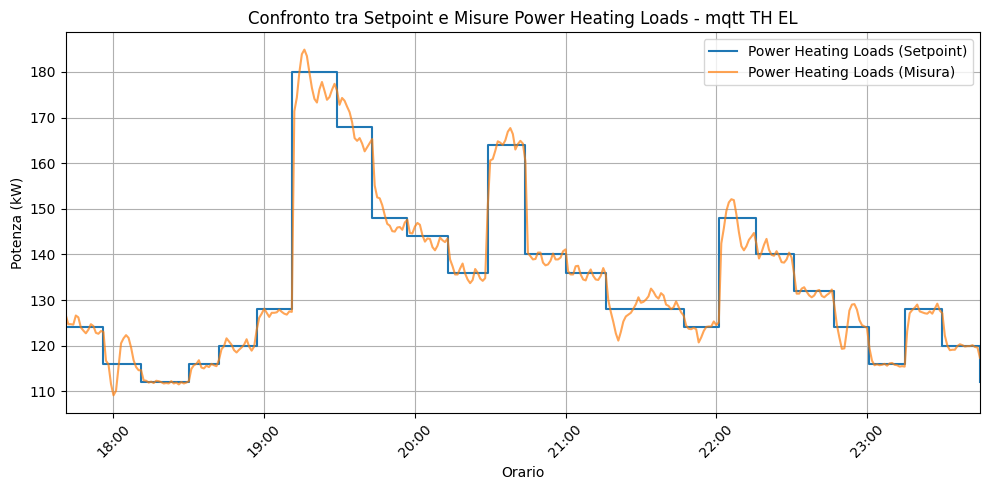

In [133]:
plt.figure(figsize=(10, 5))


P_values = df_th['HeatingLoads'].apply(lambda x: x['S700_HL4']['ThermalPower'])
P_sum_values = df_th['HeatingLoads'].apply(lambda x: x['S700_HL1']['ThermalPower']) + df_th['HeatingLoads'].apply(lambda x: x['S700_HL2']['ThermalPower']) + df_th['HeatingLoads'].apply(lambda x: x['S700_HL3']['ThermalPower']) + df_th['HeatingLoads'].apply(lambda x: x['S700_HL4']['ThermalPower'])

P_sum_measure = -df_meas_TH_HeatingLoads['Power701'] - df_meas_TH_HeatingLoads['Power711'] - df_meas_TH_HeatingLoads['Power721'] - df_meas_TH_HeatingLoads['Power731']

# Plot dei setpoint
plt.step(P_sum_values.index, P_sum_values, where='post', label='Power Heating Loads (Setpoint)')


# Plot delle misure
plt.plot(df_meas_TH_HeatingLoads['Time'], P_sum_measure, label='Power Heating Loads (Misura)', alpha=0.7)

# Formattazione
plt.xlabel("Orario")
plt.ylabel("Potenza (kW)")
plt.title("Confronto tra Setpoint e Misure Power Heating Loads - mqtt TH EL")
plt.xlim(df_meas_TH_HeatingLoads['Time'].min(), df_meas_TH_HeatingLoads['Time'].max())
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Plot Setpoint e misure carichi

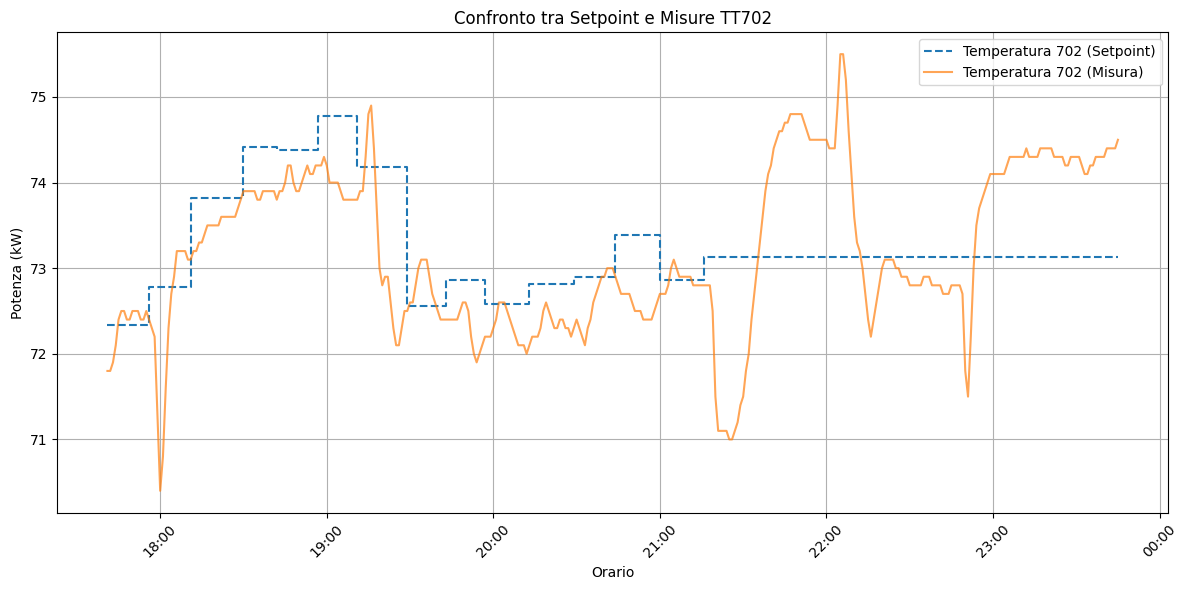

In [14]:
plt.figure(figsize=(12, 6))

# Estrai i valori 'm' per ciascun sistema
T_in_values = df_th['HeatingLoads'].apply(lambda x: x['S700_HL3']['T_in'])
# Plot dei setpoint
plt.step(T_in_values.index, T_in_values, where='post', label='Temperatura 702 (Setpoint)', linestyle='--')

# Plot delle misure
plt.plot(df_meas_TH_HeatingLoads['Time'], df_meas_TH_HeatingLoads['TT722'], label='Temperatura 702 (Misura)', alpha=0.7)

# Formattazione
plt.xlabel("Orario")
plt.ylabel("Potenza (kW)")
plt.title("Confronto tra Setpoint e Misure TT702")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Caricamento dei dati EL
Carichiamo il file JSON contenente le soluzioni dell'MPC.

In [73]:
# 1. Import delle librerie
import os
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import re
from datetime import datetime

# === Configura il percorso della cartella con i file JSON ===
folder_path_EL = 'C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/EL/SolutionData/'  # Cambia questo percorso se i file sono in una cartella diversa
json_files_EL = [f for f in os.listdir(folder_path_EL) if f.startswith("Solution") and f.endswith(".json")]



# === Lista di chiavi da cui vogliamo estrarre i setpoint iniziali ===
target_keys = {
    "Async": ["Out1", "GenIn"],
    "ESS4": ["P_ch", "P_dch", "P_stor", "En"],
    "MainLoad": ["Power"],
    "ElectricGrid": ["P_exch"],
    "TH": ["P_exch"]
}

print(target_keys)

{'Async': ['Out1', 'GenIn'], 'ESS4': ['P_ch', 'P_dch', 'P_stor', 'En'], 'MainLoad': ['Power'], 'ElectricGrid': ['P_exch'], 'TH': ['P_exch']}


In [ ]:

# === Carica il primo file JSON ===
first_file_path = os.path.join(folder_path_EL, json_files_EL[55])
with open(first_file_path, 'r') as f:
    data = json.load(f)

# === Estrai i valori di ElectricGrid -> P_exch ===
p_exch_values = data.get("ElectricGrid", {}).get("P_exch", [])

# === Plotta i valori ===
plt.figure(figsize=(10, 5))
plt.plot(p_exch_values, label='ElectricGrid - P_exch')
plt.xlabel('Indice')
plt.ylabel('P_exch')
plt.title('Andamento di ElectricGrid → P_exch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Salvataggio valori iniziali dei risultati dell'ottimizzazione ad ogni timestamp

In [74]:

# Funzione per estrarre l'indice numerico dopo '_t'
def extract_index(filename):
    match = re.search(r'_t(\d+)', filename)
    return int(match.group(1)) if match else -1

# Ordina i file in base all'indice numerico
json_files_sorted_EL = sorted(json_files_EL, key=extract_index)

# Contenitore dei setpoint
setpoints_EL = []

for filename in json_files_sorted_EL:
    file_path = os.path.join(folder_path_EL, filename)
    with open(file_path, 'r') as f:
        data = json.load(f)

    row = {"File": filename}
    
    # Imposta la data di inizio (esempio: 2025-10-07)
    start_date = datetime(2025, 8, 5)                                 ########################################################
    
    # Estrai orario dal nome del file (ultime due coppie numeriche)
    parts = filename.replace('.json', '').split('_')
    if len(parts) >= 3:
        hour = int(parts[-2])
        minute = int(parts[-1])
        # Crea solo l'orario
        time_only = datetime.strptime(f"{hour}_{minute}", "%H_%M").time()
        # Se l'orario è >= 00:00 e < 12:00, considera giorno successivo
        if hour < 12:
            day = start_date + timedelta(days=1)
        else:
            day = start_date
        # Combina giorno e orario
        time_obj = datetime.combine(day.date(), time_only)
    else:
        raise ValueError(f"Formato nome file non valido: {filename}")

    for system, variables in target_keys.items():
        for var in variables:
            try:
                val = data[system][var][0]
                row[f"{system}_{var}"] = val
            except KeyError:
                row[f"{system}_{var}"] = None
                
    row["Time"] = time_obj
    setpoints_EL.append(row)

#display(setpoints_EL[:5])  # Mostra le prime 5 righe per verifica

# === Crea DataFrame e visualizza ===
from datetime import datetime, timedelta
df_EL = pd.DataFrame(setpoints_EL)


df_EL.set_index("Time", inplace=True)
#display(df_EL.tail())

Plot setpoint carica e scarica ESS4

In [ ]:
if 'ESS4_P_ch' in df_EL.columns and 'ESS4_P_dch' in df_EL.columns:
    plt.figure(figsize=(10, 5))
    plt.plot(-df_EL['ESS4_P_ch'], label='ESS4_P_ch (Setpoint)')
    plt.plot(df_EL['ESS4_P_dch'], label='ESS4_P_dch (Setpoint)')
    plt.xlabel("Scenario/File index")
    plt.ylabel("Setpoint iniziale")
    plt.title("Setpoint iniziali da file JSON")
    plt.legend()
    plt.grid(True)

    # 👉 Mostra solo l'orario sull'asse X
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    
    plt.show()

plt.figure(figsize=(10, 5))
plt.step(df_EL['MainLoad_Power'].index, df_EL['MainLoad_Power'], where='post', label='MainLoad_Power (Setpoint)')
plt.xlabel("Scenario/File index")
plt.ylabel("Setpoint iniziale")
plt.title("Setpoint iniziali da file JSON")
plt.legend()
plt.grid(True)
# 👉 Mostra solo l'orario sull'asse X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Salvataggio misure reali da file .csv

In [ ]:
import pandas as pd

# Carica il file CSV e interpreta la colonna 'Time' come datetime
df_meas_EL = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/Electric facility-data-as-joinbyfield-2025-08-06 08_43_06.csv", parse_dates=['Time'])
# Visualizza le prime righe per confermare

def filter_df_by_file_times(df, sorted_json_files):
    """
    Filtra il DataFrame `df` per includere solo le righe con orari compresi
    tra quelli indicati nei nomi del primo e dell'ultimo file in `sorted_json_files_TH`.
    
    I nomi dei file devono contenere l'orario nel formato '_HH_MM' prima dell'estensione '.json'.
    La colonna 'Time' del DataFrame deve essere in formato datetime.
    """
    
    def extract_time_from_filename(filename):
        match = re.search(r'_(\d{2})_(\d{2})', filename)
        if match:
            hour, minute = match.groups()
            return datetime.strptime(f"{hour}:{minute}", "%H:%M").time()
        return None

    # Estrai orari dai file
    start_time = extract_time_from_filename(sorted_json_files[0])
    end_time = extract_time_from_filename(sorted_json_files[-1])

    if start_time is None or end_time is None:
        raise ValueError("Impossibile estrarre orari validi dai nomi dei file.")

    # Assicurati che la colonna 'Time' sia in formato datetime
    df['Time'] = pd.to_datetime(df['Time'])

    # Filtra il DataFrame per orario
    df_filtered = df[df['Time'].dt.time.between(start_time, end_time)]

    return df_filtered


df_meas_EL = filter_df_by_file_times(df_meas_EL, json_files_sorted_EL)

display(df_meas_EL.keys())


Plot misure e setpoint su stesso grafico per confronto

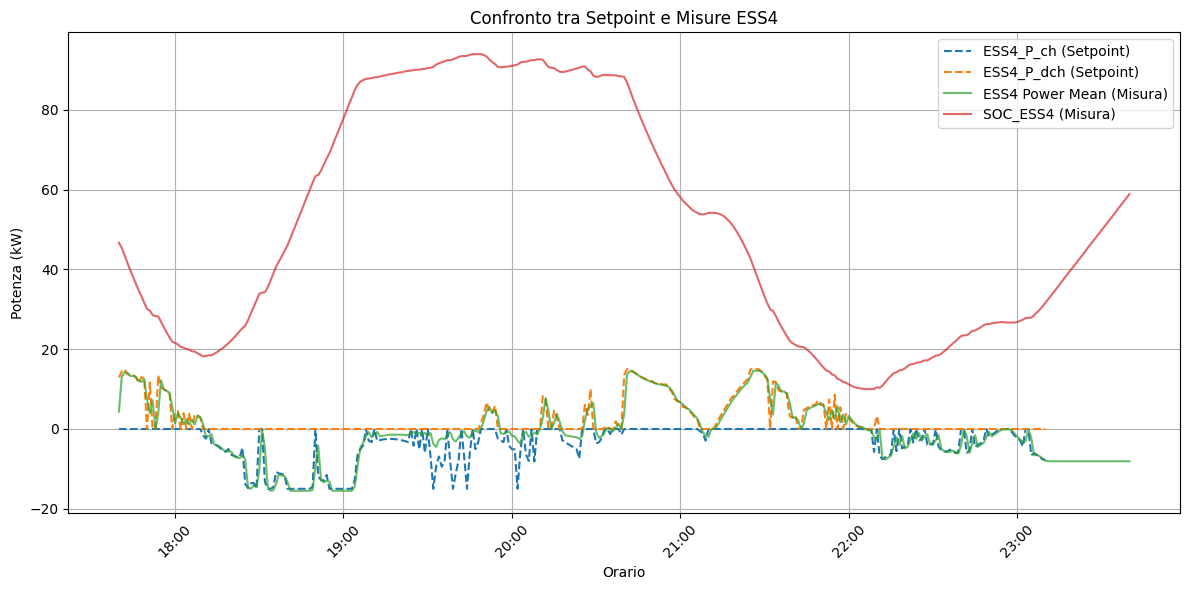

In [86]:

# Assumiamo che df e df_meas_EL siano già caricati e contengano le colonne corrette
plt.figure(figsize=(12, 6))

# Plot dei setpoint
plt.plot(-df_EL['ESS4_P_ch'], label='ESS4_P_ch (Setpoint)', linestyle='--')
plt.plot(df_EL['ESS4_P_dch'], label='ESS4_P_dch (Setpoint)', linestyle='--')

# Plot delle misure
plt.plot(df_meas_EL['Time'], df_meas_EL['ESS4 power.mean'], label='ESS4 Power Mean (Misura)', alpha=0.7)
plt.plot(df_meas_EL['Time'], df_meas_EL['SOC_ESS4'], label='SOC_ESS4 (Misura)', alpha=0.7)


# Formattazione
plt.xlabel("Orario")
plt.ylabel("Potenza (kW)")
plt.title("Confronto tra Setpoint e Misure ESS4")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


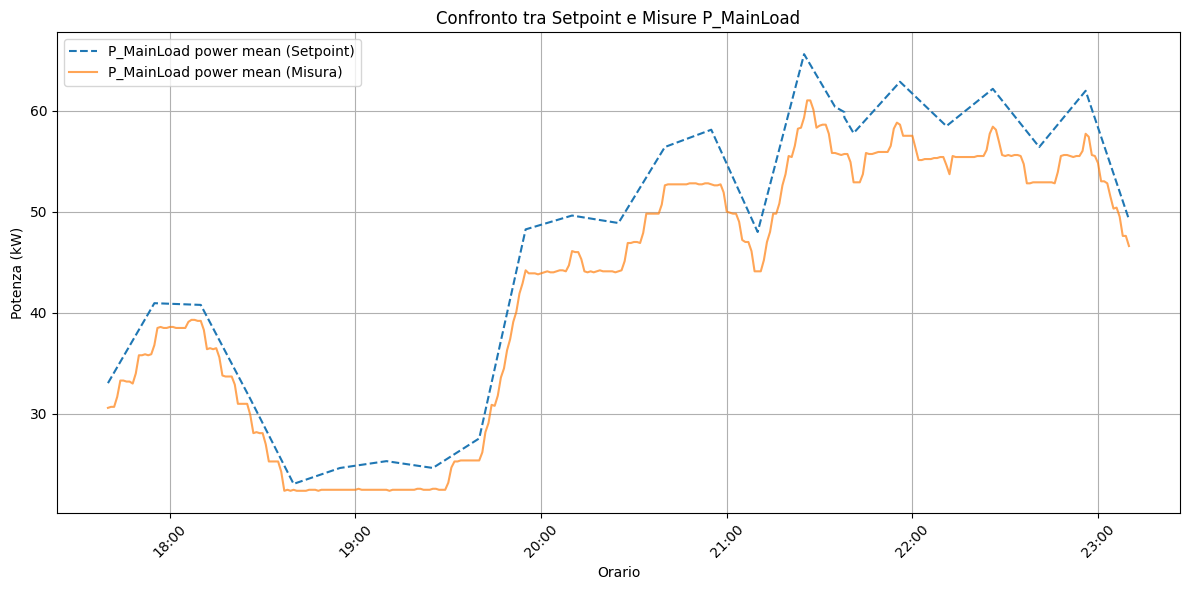

In [77]:
# Assumiamo che df e df_meas_EL siano già caricati e contengano le colonne corrette
plt.figure(figsize=(12, 6))

# Plot dei setpoint
plt.plot(df_EL['MainLoad_Power'], label='P_MainLoad power mean (Setpoint)', linestyle='--')

# Plot delle misure
plt.plot(df_meas_EL['Time'], df_meas_EL['P_MainLoad power.mean'], label='P_MainLoad power mean (Misura)', alpha=0.7)
#plt.plot(df_meas_EL['Time'], df_meas_EL['SOC_ESS4'], label='SOC_ESS4 (Misura)', alpha=0.7)

# Formattazione
plt.xlabel("Orario")
plt.ylabel("Potenza (kW)")
plt.title("Confronto tra Setpoint e Misure P_MainLoad")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Caricamento dati HL

In [78]:
# 1. Import delle librerie
import os
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import re
from datetime import datetime, timedelta


# === Configura il percorso della cartella con i file JSON ===
folder_path_HL = 'C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/HL_MPC/SolutionData/'  # Cambia questo percorso se i file sono in una cartella diversa
json_files_HL = [f for f in os.listdir(folder_path_HL) if f.startswith("Solution") and f.endswith(".json")]


def get_numeric_sort_key(filename):
    """
    Extracts the numeric part from filenames like 'Solution_tX_tHl0_12_43.json'
    for numerical sorting.
    """
    match = re.search(r'_t(\d+)_', filename)
    if match:
        return int(match.group(1))
    return float('inf') # Put files without a number at the end

# Sort the files numerically
sorted_json_files_HL = sorted(json_files_HL, key=get_numeric_sort_key)

#display(sorted_json_files_HL[:5])  # Mostra i primi 5 file ordinati per verifica

Salvataggio dei valori iniziali di ogni sequenza

In [ ]:
def extract_first_values(d):
    result = {}
    for key, value in d.items():
        if isinstance(value, dict):
            nested = extract_first_values(value)
            if nested:
                result[key] = nested
        elif isinstance(value, list) and value:
            result[key] = value[0]
    return result

# Lista per raccogliere tutti i setpoints
all_setpoints_HL = []
setpoints_HL = []
# Itera sui file ordinati
for filename in sorted_json_files_HL:
    file_path = os.path.join(folder_path_HL, filename)
    with open(file_path, 'r') as f:
        data = json.load(f)

    setpoints_HL = {
        key: extract_first_values(data[key])
        for key in ['TH', 'EL', 'EH']
        if key in data
    }

    # Aggiungi il nome del file per riferimento
    setpoints_HL["File"] = filename
    # Imposta la data di inizio (esempio: 2025-10-07)
    start_date = datetime(2025, 8, 5)                               ########################################################
    
    # Estrai orario dal nome del file (ultime due coppie numeriche)
    parts = filename.replace('.json', '').split('_')
    if len(parts) >= 3:
        hour = int(parts[-2])
        minute = int(parts[-1])
        # Crea solo l'orario
        time_only = datetime.strptime(f"{hour}_{minute}", "%H_%M").time()
        # Se l'orario è >= 00:00 e < 12:00, considera giorno successivo
        if hour < 12:
            day = start_date + timedelta(days=1)
        else:
            day = start_date
        # Combina giorno e orario
        time_obj = datetime.combine(day.date(), time_only)
    else:
        raise ValueError(f"Formato nome file non valido: {filename}")

    # Aggiungi il timestamp e il nome del file
    setpoints_HL["Time"] = time_obj
    all_setpoints_HL.append(setpoints_HL)

#display(all_setpoints_HL[:5])  # Mostra le prime 5 righe per verifica
df_HL = pd.DataFrame(all_setpoints_HL)

df_HL.set_index("Time", inplace=True)


serie_temporale = df_HL['EL'].apply(lambda x: x['ElectricGrid']['P_exch'])



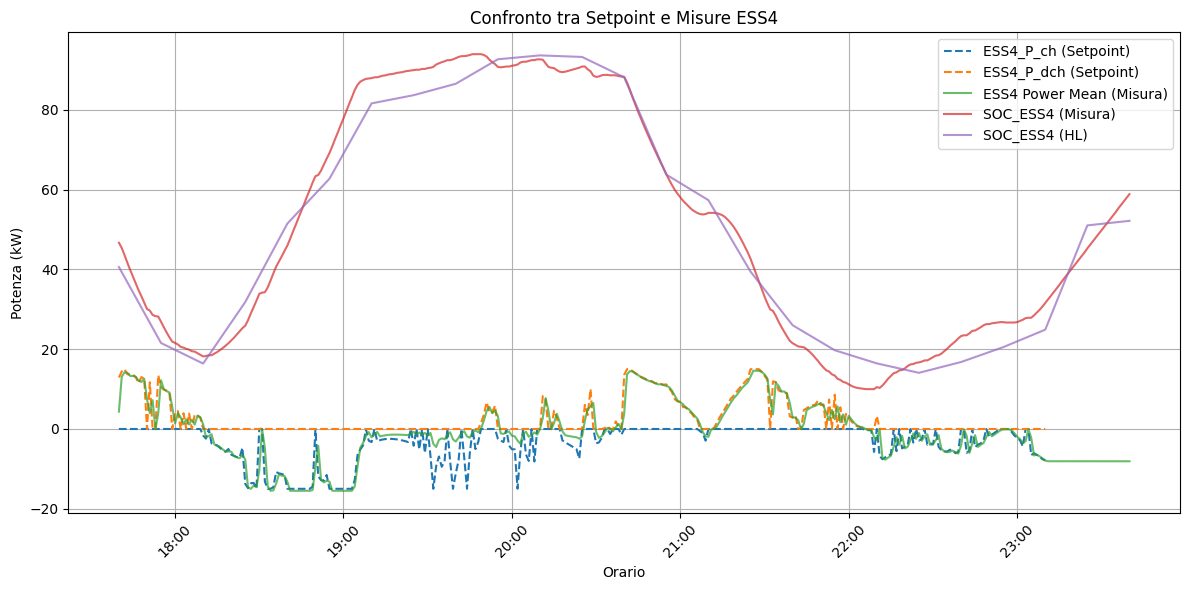

In [136]:
def extract_first_values_SOC(d):
    result = {}
    for key, value in d.items():
        if isinstance(value, dict):
            nested = extract_first_values_SOC(value)
            if nested:
                result[key] = nested
        elif isinstance(value, list) and value:
            result[key] = value[1]
    return result

# Lista per raccogliere tutti i setpoints
all_setpoints_HL = []
setpoints_HL = []
# Itera sui file ordinati
for filename in sorted_json_files_HL:
    file_path = os.path.join(folder_path_HL, filename)
    with open(file_path, 'r') as f:
        data = json.load(f)

    setpoints_HL = {
        key: extract_first_values_SOC(data[key])
        for key in ['TH', 'EL', 'EH']
        if key in data
    }

    # Aggiungi il nome del file per riferimento
    setpoints_HL["File"] = filename
    # Imposta la data di inizio (esempio: 2025-10-07)
    start_date = datetime(2025, 8, 5)                               ########################################################
    
    # Estrai orario dal nome del file (ultime due coppie numeriche)
    parts = filename.replace('.json', '').split('_')
    if len(parts) >= 3:
        hour = int(parts[-2])
        minute = int(parts[-1])
        # Crea solo l'orario
        time_only = datetime.strptime(f"{hour}_{minute}", "%H_%M").time()
        # Se l'orario è >= 00:00 e < 12:00, considera giorno successivo
        day = start_date
        # Combina giorno e orario
        time_obj = datetime.combine(day.date(), time_only)
    else:
        raise ValueError(f"Formato nome file non valido: {filename}")

    # Aggiungi il timestamp e il nome del file
    setpoints_HL["Time"] = time_obj
    all_setpoints_HL.append(setpoints_HL)

#display(all_setpoints_HL[:5])  # Mostra le prime 5 righe per verifica
df_HL_SOC = pd.DataFrame(all_setpoints_HL)
df_HL_SOC.set_index("Time", inplace=True)

SOC_HL = df_HL_SOC['EL'].apply(lambda x: x['EE_AC']['E_int']/60 *100)


# Assumiamo che df e df_meas_EL siano già caricati e contengano le colonne corrette
plt.figure(figsize=(12, 6))

# Plot dei setpoint
plt.plot(-df_EL['ESS4_P_ch'], label='ESS4_P_ch (Setpoint)', linestyle='--')
plt.plot(df_EL['ESS4_P_dch'], label='ESS4_P_dch (Setpoint)', linestyle='--')

# Plot delle misure
plt.plot(df_meas_EL['Time'], df_meas_EL['ESS4 power.mean'], label='ESS4 Power Mean (Misura)', alpha=0.7)
plt.plot(df_meas_EL['Time'], df_meas_EL['SOC_ESS4'], label='SOC_ESS4 (Misura)', alpha=0.7)
plt.plot(SOC_HL.index, SOC_HL, label='SOC_ESS4 (HL)', alpha=0.7)

# Formattazione
plt.xlabel("Orario")
plt.ylabel("Potenza (kW)")
plt.title("Confronto tra Setpoint e Misure ESS4")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Funzione per navigare i dati e plottare
def plot_all_nested_data(df, colonna_principale, plot_all, livello = None):
    """
    df: il DataFrame (es. df_HL)
    colonna_principale: 'TH' o 'EL'
    """
    # Prende la prima riga come modello per trovare la struttura
    struttura = df.iloc[0][colonna_principale]

    if plot_all:
        for secondo_livello in struttura:
            sotto_blocco = struttura[secondo_livello]

            for variabile in sotto_blocco:
                # Estrae i valori per tutta la colonna in funzione del tempo
                serie_temporale = df[colonna_principale].apply(lambda x: x[secondo_livello][variabile])

                # Plot
                plt.figure(figsize=(10, 4))
                plt.step(df.index, serie_temporale, where='post', label=f"{colonna_principale} → {secondo_livello} → {variabile}")
                plt.title(f"{colonna_principale} / {secondo_livello} / {variabile}")
                plt.xlabel("Tempo")
                plt.ylabel(variabile)
                plt.xlim(df.index[0], df.index[-1])  # Imposta limiti X in base al DataFrame
                plt.grid(True)
                plt.legend()
                #plt.tight_layout()
                plt.show()
    
    # Se plot_all è False, plottiamo solo H_HT (Esempio per plottare solamente una struttura specifica)
    else:
        for variabile in struttura[livello]:
                # Estrae i valori per tutta la colonna in funzione del tempo
                serie_temporale = df[colonna_principale].apply(lambda x: x[livello][variabile])

                # Plot
                plt.figure(figsize=(10, 4))
                plt.step(df.index, serie_temporale, where='post', label=f"{colonna_principale} → {livello} → {variabile}")
                plt.title(f"{colonna_principale} / {livello} / {variabile}")
                plt.xlabel("Tempo")
                plt.ylabel(variabile)
                plt.grid(True)
                plt.legend()
                #plt.tight_layout()
                plt.show()
        

# Usa la funzione per TH ed EL
plot_all_nested_data(df_HL, 'TH', plot_all=True)
plot_all_nested_data(df_HL, 'EL', plot_all=True)
#plot_all_nested_data(df_HL, 'EH', plot_all=True)

In [81]:
# Carica il file CSV e interpreta la colonna 'Time' come datetime
df_meas_TH_Generators = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/TH-MPC set points and measurements _ generation-data-as-joinbyfield-2025-08-06 08_43_14.csv", parse_dates=['Time'])

# Carica il file CSV e interpreta la colonna 'Time' come datetime
df_meas_EL = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/Electric facility-data-as-joinbyfield-2025-08-06 08_43_06.csv", parse_dates=['Time'])


def filter_df_by_file_times(df, sorted_json_files):
    """
    Filtra il DataFrame `df` per includere solo le righe con orari compresi
    tra quelli indicati nei nomi del primo e dell'ultimo file in `sorted_json_files_TH`.
    
    I nomi dei file devono contenere l'orario nel formato '_HH_MM' prima dell'estensione '.json'.
    La colonna 'Time' del DataFrame deve essere in formato datetime.
    """
    
    def extract_time_from_filename(filename):
        match = re.search(r'_(\d{2})_(\d{2})', filename)
        if match:
            hour, minute = match.groups()
            return datetime.strptime(f"{hour}:{minute}", "%H:%M").time()
        return None

    # Estrai orari dai file
    start_time = extract_time_from_filename(sorted_json_files[0])
    end_time = extract_time_from_filename(sorted_json_files[-1])

    if start_time is None or end_time is None:
        raise ValueError("Impossibile estrarre orari validi dai nomi dei file.")

    # Assicurati che la colonna 'Time' sia in formato datetime
    df['Time'] = pd.to_datetime(df['Time'])

    # Filtra il DataFrame per orario
    df_filtered = df[df['Time'].dt.time.between(start_time, end_time)]

    return df_filtered


df_meas_TH_Generators = filter_df_by_file_times(df_meas_TH_Generators, sorted_json_files_HL)
df_meas_EL = filter_df_by_file_times(df_meas_EL, sorted_json_files_HL)

display(df_meas_TH_Generators["Pel_CHP"].head())

1059    50.0
1060    50.0
1061    50.0
1062    50.0
1063    50.0
Name: Pel_CHP, dtype: float64

In [ ]:
# Uniamo i due dataframe sulla colonna Time
df_merged = pd.merge(df_meas_EL, df_meas_TH_Generators, on='Time', how='inner')

# Somma riga per riga delle colonne desiderate
df_merged['Total_Power'] = (
    df_merged['P_Async'] +
    df_merged['ESS4 power.mean'] +
    df_merged['Pel_CHP'] -
    df_merged['P_MainLoad power.mean'] 
)

# Creiamo il nuovo dataframe solo con Time e il totale
df_result = df_merged[['Time', 'Total_Power']]

# Visualizzazione (opzionale)
print(df_result.head())


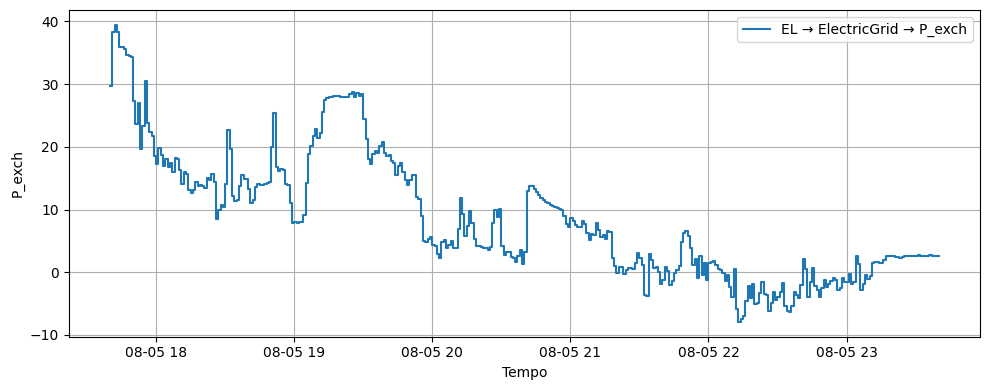

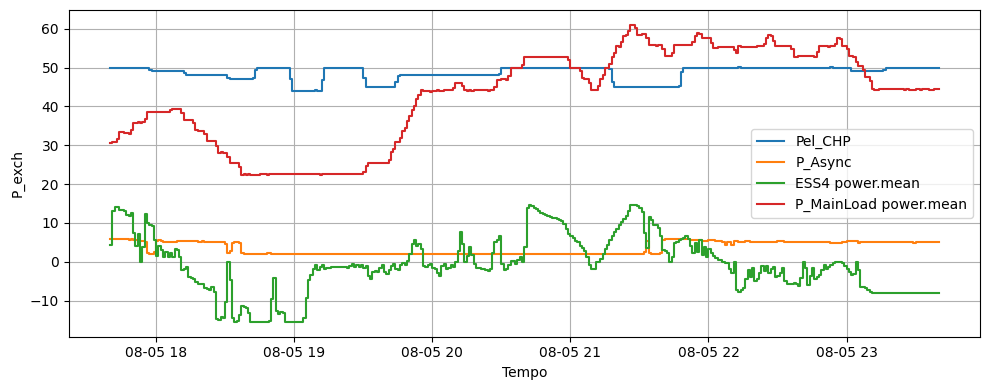

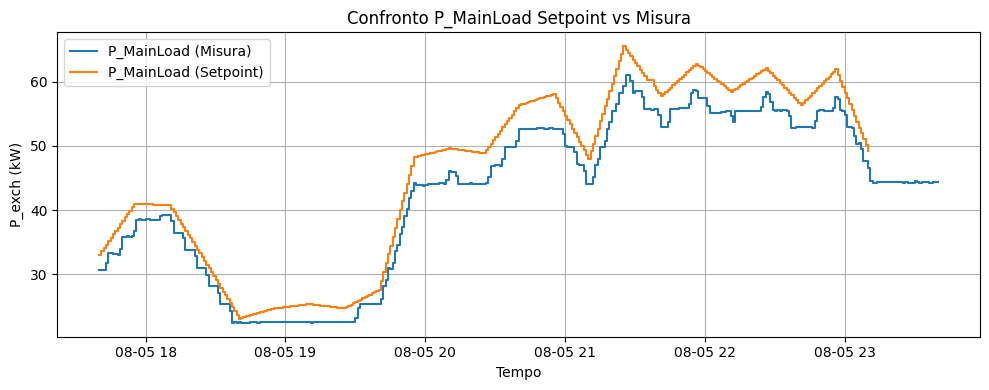

In [113]:
plt.figure(figsize=(10, 4))
plt.step(df_result['Time'], df_result['Total_Power'], where='post', label=f"EL → ElectricGrid → P_exch")

plt.xlabel("Tempo")
plt.ylabel('P_exch')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.step(df_merged['Time'], df_merged['Pel_CHP'], where='post', label=f"Pel_CHP")
plt.step(df_merged['Time'], df_merged['P_Async'], where='post', label=f"P_Async")
plt.step(df_merged['Time'], df_merged['ESS4 power.mean'], where='post', label=f"ESS4 power.mean")
plt.step(df_merged['Time'], df_merged['P_MainLoad power.mean'], where='post', label=f"P_MainLoad power.mean")
plt.xlabel("Tempo")
plt.ylabel('P_exch')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.step(df_merged['Time'], df_merged['P_MainLoad power.mean'], where='post', label=f"P_MainLoad (Misura)")
plt.step(df_EL['MainLoad_Power'].index, df_EL['MainLoad_Power'], where='post', label='P_MainLoad (Setpoint)')
plt.xlabel("Tempo")
plt.ylabel('P_exch (kW)')
plt.title("Confronto P_MainLoad Setpoint vs Misura")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

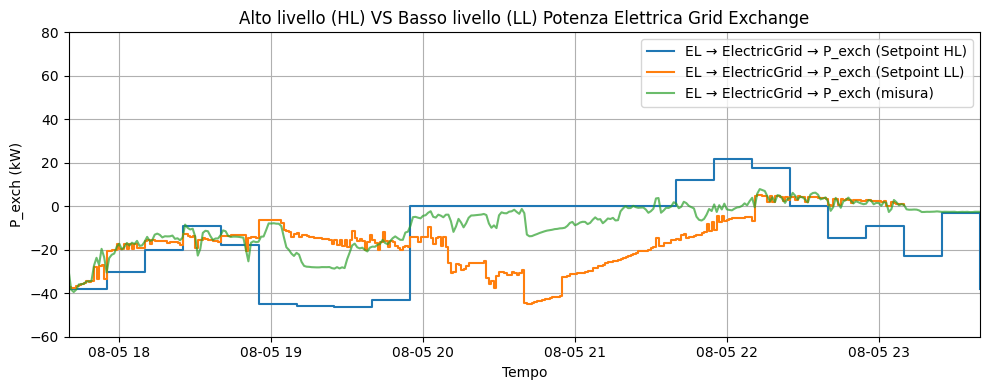

In [134]:
P_el_exc = df_HL['EL'].apply(lambda x: x['ElectricGrid']['P_exch'])

# Plot
plt.figure(figsize=(10, 4))
plt.step(P_el_exc.index, P_el_exc, where='post', label="EL → ElectricGrid → P_exch (Setpoint HL)")
plt.step(df_EL['ElectricGrid_P_exch'].index, df_EL['ElectricGrid_P_exch'], where='post', label='EL → ElectricGrid → P_exch (Setpoint LL)')
# Plot delle misure
plt.plot(df_result['Time'], -df_result['Total_Power'], label='EL → ElectricGrid → P_exch (misura)', alpha=0.7)
plt.title('Alto livello (HL) VS Basso livello (LL) Potenza Elettrica Grid Exchange')
plt.xlim(df_merged['Time'].min(), df_merged['Time'].max())
plt.ylim(-60,80)
plt.xlabel("Tempo")
plt.ylabel('P_exch (kW)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
        

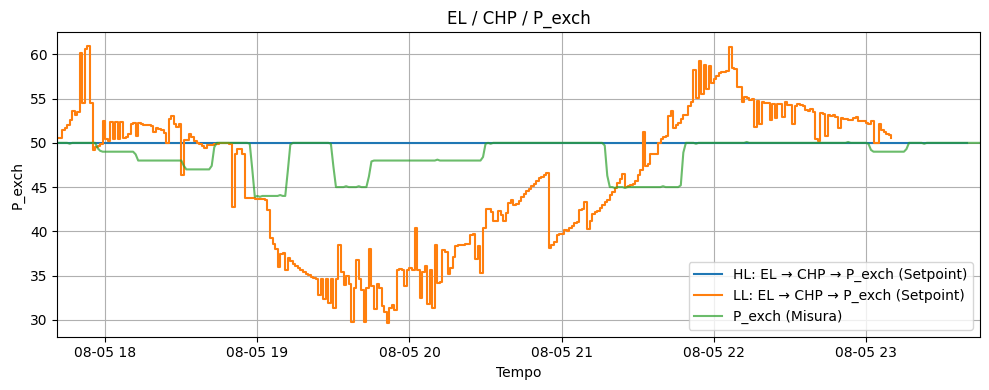

In [35]:
P_el_CHP = df_HL['EL'].apply(lambda x: x['TH']['P_exch'])

# Plot
plt.figure(figsize=(10, 4))
plt.step(P_el_CHP.index, P_el_CHP, where='post', label=f"HL: EL → CHP → P_exch (Setpoint)")
plt.step(df_EL['TH_P_exch'].index, df_EL['TH_P_exch'], where='post', label='LL: EL → CHP → P_exch (Setpoint)')

# Plot delle misure
plt.plot(df_meas_TH_Generators['Time'], df_meas_TH_Generators['Pel_CHP'], label='P_exch (Misura)', alpha=0.7)
plt.title(f"EL / CHP / P_exch")
plt.xlim(df_meas_TH_Generators['Time'].min(), df_meas_TH_Generators['Time'].max())
plt.xlabel("Tempo")
plt.ylabel('P_exch')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

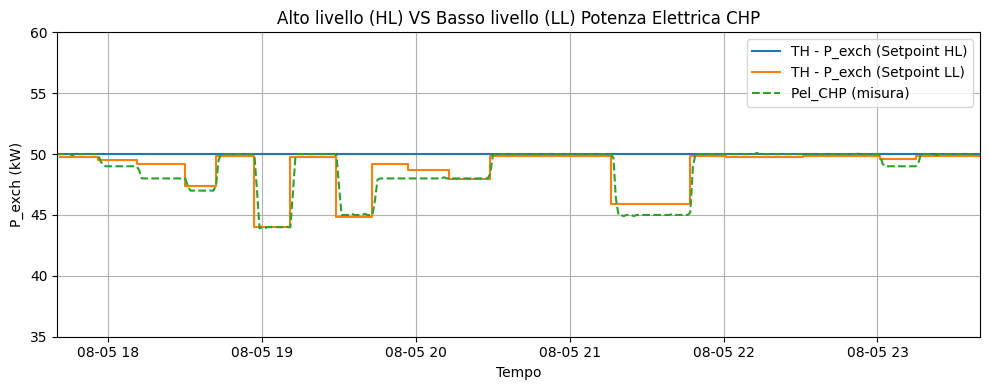

In [103]:
# Estrae i valori per tutta la colonna in funzione del tempo
serie_temporale = df_HL["EL"].apply(lambda x: x["TH"]["P_exch"])
sp_LL_CHP = df_th['Generators'].apply(lambda x: x['S500']['Out1'])

plt.figure(figsize=(10, 4))
plt.step(df_HL.index, serie_temporale, where='post', label='TH - P_exch (Setpoint HL)')

# Plot delle misure
plt.step(sp_LL_CHP.index, sp_LL_CHP,  where='post', label='TH - P_exch (Setpoint LL)')
plt.plot(df_meas_TH_Generators['Time'], df_meas_TH_Generators['Pel_CHP'], label='Pel_CHP (misura)', linestyle='--')
plt.xlabel("Tempo")
plt.ylabel("P_exch (kW)")
plt.xlim(df_HL.index[0], df_HL.index[-1])  # Imposta limiti X in base al DataFrame
plt.ylim(35,60)
plt.title('Alto livello (HL) VS Basso livello (LL) Potenza Elettrica CHP')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
import pandas as pd

# Carica il file CSV e interpreta la colonna 'Time' come datetime
df_meas_TH_HeatingLoads = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/TH-MPC set points and measurements _ heating loads-data-as-joinbyfield-2025-08-06 08_43_23.csv", parse_dates=['Time'])

# Carica il file CSV e interpreta la colonna 'Time' come datetime
df_meas_TH_Generators = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/TH-MPC set points and measurements _ generation-data-as-joinbyfield-2025-08-06 08_43_14.csv", parse_dates=['Time'])

df_meas_TH_power  = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/Thermal power-data-as-joinbyfield-2025-08-06 08_42_25.csv", parse_dates=['Time'])



def filter_df_by_file_times(df, sorted_json_files):
    """
    Filtra il DataFrame `df` per includere solo le righe con orari compresi
    tra quelli indicati nei nomi del primo e dell'ultimo file in `sorted_json_files_TH`.
    
    I nomi dei file devono contenere l'orario nel formato '_HH_MM' prima dell'estensione '.json'.
    La colonna 'Time' del DataFrame deve essere in formato datetime.
    """
    
    def extract_time_from_filename(filename):
        match = re.search(r'_(\d{2})_(\d{2})', filename)
        if match:
            hour, minute = match.groups()
            return datetime.strptime(f"{hour}:{minute}", "%H:%M").time()
        return None

    # Estrai orari dai file
    start_time = extract_time_from_filename(sorted_json_files[0])
    end_time = extract_time_from_filename(sorted_json_files[-1])

    if start_time is None or end_time is None:
        raise ValueError("Impossibile estrarre orari validi dai nomi dei file.")

    # Assicurati che la colonna 'Time' sia in formato datetime
    df['Time'] = pd.to_datetime(df['Time'])

    # Filtra il DataFrame per orario
    df_filtered = df[df['Time'].dt.time.between(start_time, end_time)]

    return df_filtered


df_meas_TH_HeatingLoads = filter_df_by_file_times(df_meas_TH_HeatingLoads, sorted_json_files_TH)
df_meas_TH_Generators = filter_df_by_file_times(df_meas_TH_Generators, sorted_json_files_TH)
df_meas_TH_power = filter_df_by_file_times(df_meas_TH_power, sorted_json_files_TH)


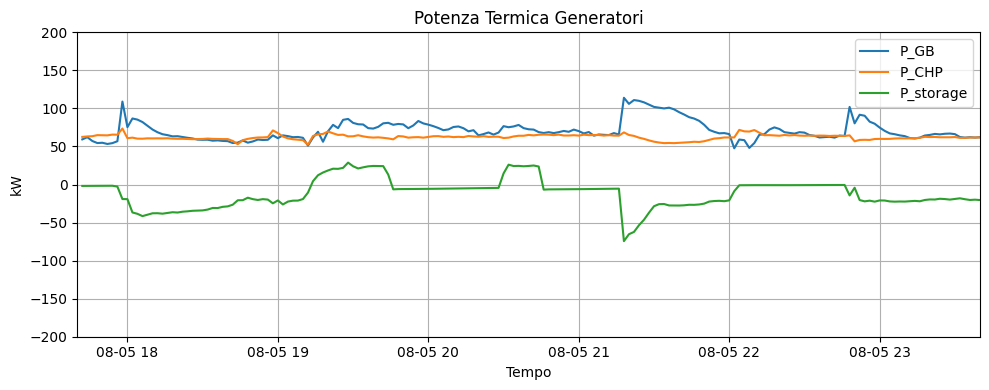

In [108]:
# Estrae i valori per tutta la colonna in funzione del tempo

df_meas_TH_power['Power100'] = pd.to_numeric(df_meas_TH_power['Power100'], errors='coerce')


plt.figure(figsize=(10, 4))

# Plot delle misure
plt.plot(df_meas_TH_power['Time'], df_meas_TH_power['Power100'], label='P_GB')
plt.plot(df_meas_TH_power['Time'], df_meas_TH_power['Power500'], label='P_CHP')
plt.plot(df_meas_TH_power['Time'], df_meas_TH_power['Power200'], label='P_storage')
#plt.plot(df__meas_TH_power['Time'], df__meas_TH_power['Power400'], label='P_EB', linestyle='--')
plt.xlabel("Tempo")
plt.ylabel("kW")
plt.xlim(df_HL.index[0], df_HL.index[-1])  # Imposta limiti X in base al DataFrame
plt.ylim(-200,200)
plt.title("Potenza Termica Generatori")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [109]:
import pandas as pd
# Carica il file CSV e interpreta la colonna 'Time' come datetime
df_meas_TH_HeatingLoads = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/TH-MPC set points and measurements _ heating loads-data-as-joinbyfield-2025-08-06 08_43_23.csv", parse_dates=['Time'])

df_meas_TH_Generators = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/TH-MPC set points and measurements _ generation-data-as-joinbyfield-2025-08-06 08_43_14.csv", parse_dates=['Time'])

df_meas_TH_power  = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/Thermal power-data-as-joinbyfield-2025-08-06 08_42_25.csv", parse_dates=['Time'])

df_meas_TH_Temperature  = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/Temperature-data-as-joinbyfield-2025-08-06 08_42_42.csv", parse_dates=['Time'])

df_meas_TH_Flow  = pd.read_csv("C:/Users/anderis/OneDrive - RSE S.P.A/Documenti/GitHub/ControlloDistribuito_DERTF/DatiDERTF_Rapporto/Centralizzato_mqtt_TH_EL/Flow-data-as-joinbyfield-2025-08-06 08_42_34.csv", parse_dates=['Time'])

def filter_df_by_file_times(df, sorted_json_files):
    import re
    from datetime import datetime, time

    def extract_time(filename):
        match = re.search(r'_(\d{2})_(\d{2})', filename)
        if match:
            hour, minute = match.groups()
            return time(int(hour), int(minute))
        return None

    start_time = extract_time(sorted_json_files[0])
    end_time = extract_time(sorted_json_files[-1])

    if start_time is None or end_time is None:
        raise ValueError("Orari non trovati nei nomi dei file.")

    # Se end_time < start_time → significa che il range attraversa la mezzanotte
    if end_time < start_time:
        df_filtered = df[(df['Time'].dt.time >= start_time) | (df['Time'].dt.time <= end_time)]
    else:
        df_filtered = df[df['Time'].dt.time.between(start_time, end_time)]

    return df_filtered



df_meas_TH_HeatingLoads = filter_df_by_file_times(df_meas_TH_HeatingLoads, sorted_json_files_TH)
df_meas_TH_Generators = filter_df_by_file_times(df_meas_TH_Generators, sorted_json_files_TH)
df_meas_TH_power = filter_df_by_file_times(df_meas_TH_power, sorted_json_files_TH)
df_meas_TH_Temperature = filter_df_by_file_times(df_meas_TH_Temperature, sorted_json_files_TH)
df_meas_TH_Flow = filter_df_by_file_times(df_meas_TH_Flow, sorted_json_files_TH)

In [110]:
# Parametri
rho = 1000  # kg/m³
cp_kwh = 1.163e-3  # kWh/(kg·K)
T_ref = 0  # °C
volume_storage = 10.0  # m³
n_layers = 4
mass_per_layer = rho * (volume_storage / n_layers)  # kg

# Supponiamo di avere un DataFrame con le temperature dei layer
# Colonne: TT207, TT208, TT209, TT210
layers = ['TT207', 'TT208', 'TT209', 'TT210']

# Calcolo energia interna layer-by-layer
E_storage = pd.Series(0.0, index=df_meas_TH_Temperature.index)
for layer in layers:
    E_storage += mass_per_layer * cp_kwh * (df_meas_TH_Temperature[layer] - T_ref)


E_storage.index = df_meas_TH_Temperature['Time']

print(E_storage.head())

Time
2025-08-05 17:42:00    837.36000
2025-08-05 17:44:00    837.36000
2025-08-05 17:46:00    837.36000
2025-08-05 17:48:00    837.06925
2025-08-05 17:50:00    837.06925
dtype: float64


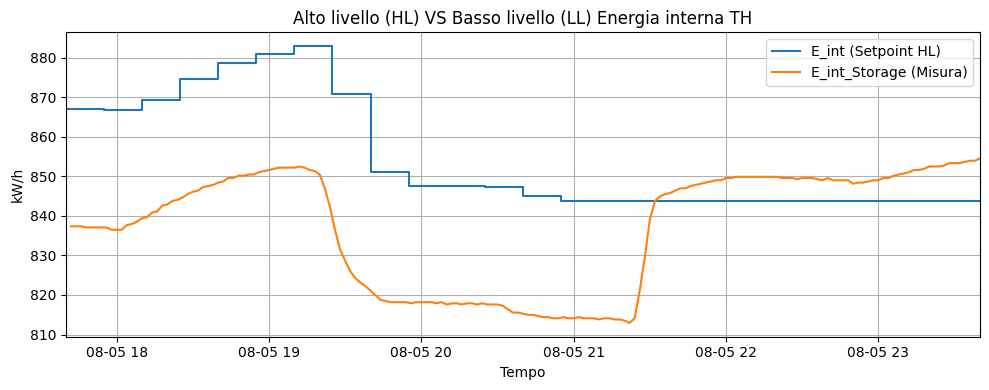

In [112]:
E_int_set = df_HL["TH"].apply(lambda x: x["H_HT"]["E_int"])

plt.figure(figsize=(10, 4))
plt.step(df_HL.index, E_int_set, where='post', label='E_int (Setpoint HL)')
plt.plot(df_meas_TH_Temperature['Time'], E_storage, label='E_int_Storage (Misura)')   #####
# Plot delle misure
plt.xlabel("Tempo")
plt.ylabel("kW/h")
plt.xlim(df_HL.index[0], df_HL.index[-1])  # Imposta limiti X in base al DataFrame
plt.grid(True)
plt.title('Alto livello (HL) VS Basso livello (LL) Energia interna TH')
#plt.ylim(750,950)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
import sys
from pathlib import Path

# Define the absolute path to the project root directory
MainDir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(MainDir)
from src.L_MPC.TH.support.ConfiguratorsFn       import ThermalFacilityConfigurator
from src.L_MPC.TH.core.CreateOCP                import CreateCasADIModel
from utils.L_MPC.plotter                        import PlotThermalNetwork

ConfigDataPath  = os.path.join(MainDir,'utils','L_MPC','ConfigData')
ProfileDataPath = os.path.join(MainDir,'utils','L_MPC','ProfileData')

print(f"ConfigDataPath: {ConfigDataPath}")
print(f"Looking for config file at: {os.path.join(ConfigDataPath, 'DER_TH_EL_EH_withEB.json')}")
print(f"Config file exists: {os.path.exists(os.path.join(ConfigDataPath, 'DER_TH_EL_EH_withEB.json'))}")

# Setting default options, that can be changed by the user from the script XXXX (to be defined)
DefaultOpts = {
        'LocalNetInConfig' : ['TH','EL','EH'],
        # Selection of the configuration to be used
        'FullConfig'            : ['S100','S200','S300','S400','S500','S700_HL1','S700_HL2','S700_HL3','S700_HL4','S700_bypass'],
        'SystemsInConfig'       : ['S100','S200','S500','S700_HL1','S700_HL2','S700_HL3','S700_HL4'],#,'S700_bypass'],
        'TESSinConfig'          : ['D201','D202'],

        # Parameters for the EMS configuration
        'json_FileName_Config'  : 'DER_TH_EL_EH_withEB.json',
        'json_FileName_Pipes'   : 'PipesList.json',
        'ConfigDataPath'        : ConfigDataPath, 

        # Demand, RES and prices profile for the EMS 
        'json_FileName_Profile' : 'DERTF_Profile_Components_EHconEB_reduced.json',
        'ProfileDataPath'       : ProfileDataPath,

        # Parameters for the simulation
        'dt'                    : 0.25,     # hours
        'Tsim'                  : 1,        # hours
        'ScaleFactor_H_HT'      : 1,        # Scale factor for thermal demand
        'T_delivery'            : 70,       # Delivery temperature
        'T_return'              : 60,       # Return temperature

        # Settings 
        'PlotNetwork'           : False,    
        'HierarchicalControl'   : False,     # True for hierarchical control, False for local control (different objective and parameters)
        }


ConfigParams    = ThermalFacilityConfigurator(DefaultOpts)

# PlotThermalNetwork(ConfigParams)

# Esegui la creazione del modello senza mostrare output a video

[_, TH_Net] = CreateCasADIModel(DefaultOpts, ConfigParams)